# Confusion Matrix Evaluation — deployed 1D CNN on the test set

Run this **after** the training notebook has produced the deployed model and
its metadata in `prepared/`. It loads the shipped model, applies the decision
threshold that was chosen on the validation set and stored at training time,
and reports the confusion matrix on the held-out, subject-grouped test set.

It reproduces the evaluation exactly:

* the **same test arrays** the training notebook uses,
* the **same stored threshold** (`prepared/v1_meta.json`), not a new one,
* the same category split (gross / fine SMM) used for per-type recall,

so the numbers here match the reported test metrics. Nothing is re-trained and
no decision is taken on the test set — the threshold is read, not fitted.

In [7]:
# ── Config: must match the training notebook ─────────────────────────
OUT_DIR = "prepared"     # where the prep + training notebooks wrote their outputs
BATCH   = 256
FIG_DIR = "figures"      # confusion-matrix PNGs are written here

import os, json, csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             average_precision_score)

os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "font.size": 10, "axes.titleweight": "bold"})

In [8]:
# ── Load the held-out test set (identical to the training notebook) ──
def load(split):
    X = np.load(f"{OUT_DIR}/X_{split}.npy").transpose(0, 2, 1).astype("float32")  # (N,90,20)
    y = np.load(f"{OUT_DIR}/y_{split}.npy").astype("float32")
    cat = np.load(f"{OUT_DIR}/cat_{split}.npy").astype(int)                        # 0 none,1 gross,2 fine
    return X, y, cat

Xte, yte, cat_te = load("test")
print("test windows:", Xte.shape[0],
      "| positives:", int(yte.sum()),
      "| negatives:", int((yte == 0).sum()))

test windows: 11932 | positives: 3268 | negatives: 8664


In [ ]:
# ── Load the deployed model and the threshold chosen at training time ─
# The metadata file carries the threshold picked on the VALIDATION set, so we
# reuse it rather than choosing a new one on the test set.
meta = json.load(open(f"{OUT_DIR}/v1_meta.json"))
THR = float(meta["threshold"])
print("deployed config:", meta.get("selected"), "| seed:", meta.get("seed"),
      "| threshold:", THR)

# The saved Keras model contains a custom Augment layer, so its class must be
# defined before the model can be loaded. It is inactive at inference (identity),
# so its exact behaviour does not affect the scores, but Keras still needs the
# class to reconstruct the graph. This definition matches the training notebook.
from tensorflow.keras import layers

@tf.keras.utils.register_keras_serializable()
class Augment(layers.Layer):
    def __init__(self, noise=0.05, scale=0.10, kp_drop_p=0.12, shift=4, n_sp=10, **kw):
        super().__init__(**kw)
        self.noise, self.scale, self.kp_drop_p, self.shift, self.n_sp = \
            noise, scale, kp_drop_p, shift, n_sp
    def build(self, input_shape):
        assert input_shape[-1] == 2 * self.n_sp, \
            f"Augment expects {2*self.n_sp} channels, got {input_shape[-1]}"
        super().build(input_shape)
    def call(self, x, training=None):
        if not training:
            return x
        b = tf.shape(x)[0]
        sp, cf = x[..., :self.n_sp], x[..., self.n_sp:]
        sp = sp + tf.random.normal(tf.shape(sp), 0.0, self.noise)
        sp = sp * tf.random.uniform([b, 1, 1], 1 - self.scale, 1 + self.scale)
        keep = tf.cast(tf.random.uniform([b, 1, self.n_sp]) > self.kp_drop_p, x.dtype)
        x = tf.concat([sp * keep, cf * keep], axis=-1)
        return tf.roll(x, tf.random.uniform([], -self.shift, self.shift + 1, dtype=tf.int32), axis=1)
    def get_config(self):
        c = super().get_config()
        c.update(noise=self.noise, scale=self.scale, kp_drop_p=self.kp_drop_p,
                 shift=self.shift, n_sp=self.n_sp)
        return c

# Prefer the Keras model; fall back to the TFLite artifact if only that exists.
def load_scores():
    keras_path = f"{OUT_DIR}/v1_model.keras"
    if os.path.exists(keras_path):
        model = tf.keras.models.load_model(
            keras_path, compile=False, custom_objects={"Augment": Augment})
        return model.predict(Xte, batch_size=BATCH, verbose=0).ravel()
    # TFLite fallback
    itp = tf.lite.Interpreter(model_path=f"{OUT_DIR}/v1_model.tflite")
    itp.allocate_tensors()
    inp, out = itp.get_input_details()[0], itp.get_output_details()[0]
    s = np.empty(len(Xte), np.float32)
    for i, x in enumerate(Xte):
        itp.set_tensor(inp["index"], x[None].astype(inp["dtype"]))
        itp.invoke()
        s[i] = float(itp.get_tensor(out["index"]).ravel()[0])
    return s

scores = load_scores()
pred = (scores >= THR).astype(int)
print("scored", len(scores), "windows at threshold", THR)

deployed config: improved | seed: 2 | threshold: 0.15
scored 11932 windows at threshold 0.15


## 1. Overall confusion matrix

Rows are the true class, columns are the predicted class. The positive class is
*window contains an SMM*; the negative class is *no action*.

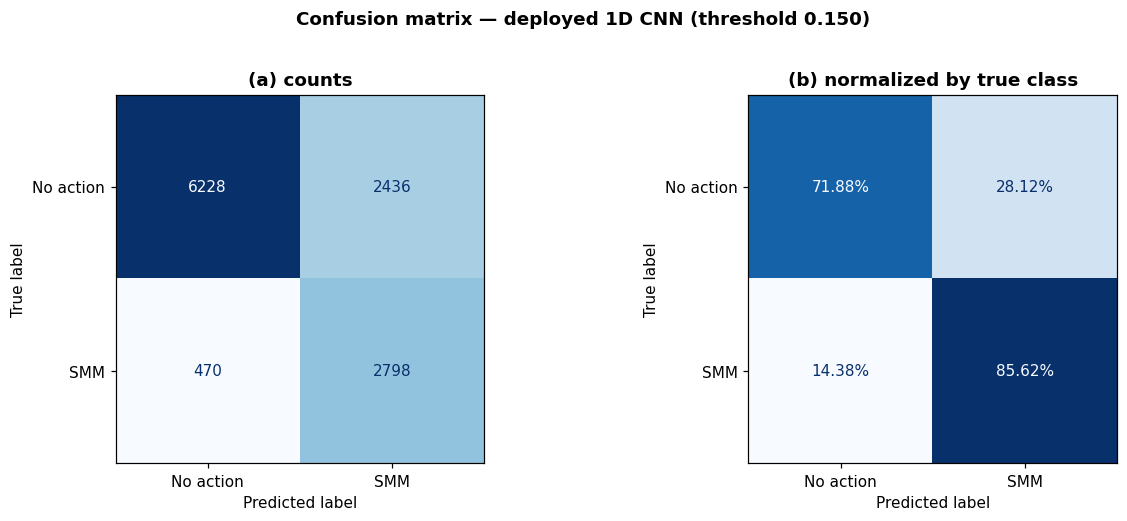

TN=6228  FP=2436
FN=470  TP=2798


In [14]:
cm = confusion_matrix(yte.astype(int), pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

# (a) raw counts
ConfusionMatrixDisplay(cm, display_labels=["No action", "SMM"]).plot(
    ax=ax[0], cmap="Blues", colorbar=False, values_format="d")
ax[0].set_title("(a) counts")

# (b) row-normalized (recall per true class)
row_tot = cm.sum(axis=1, keepdims=True)
cmn = np.divide(cm.astype(float), row_tot,
                out=np.zeros_like(cm, dtype=float), where=row_tot != 0)
ConfusionMatrixDisplay(cmn, display_labels=["No action", "SMM"]).plot(
    ax=ax[1], cmap="Blues", colorbar=False, values_format=".2%")
ax[1].set_title("(b) normalized by true class")

fig.suptitle(f"Confusion matrix — deployed 1D CNN (threshold {THR:.3f})",
             x=0.5, y=1.02, weight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/confusion_matrix.png")
plt.show()

print(f"TN={tn}  FP={fp}\nFN={fn}  TP={tp}")

## 2. Metrics derived from the matrix

These are the same quantities reported in the evaluation chapter, recomputed
here directly from the confusion matrix so they can be traced to the four cells
above.

In [11]:
prec = precision_score(yte, pred, zero_division=0)
rec  = recall_score(yte, pred, zero_division=0)
f1   = f1_score(yte, pred, zero_division=0)
spec = tn / (tn + fp) if (tn + fp) else float("nan")
prauc = average_precision_score(yte, scores)

rows = [
    ("True positives (TP)",  tp, "SMM windows correctly detected"),
    ("False negatives (FN)", fn, "SMM windows missed"),
    ("False positives (FP)", fp, "no-action windows wrongly flagged"),
    ("True negatives (TN)",  tn, "no-action windows correctly passed"),
    ("Recall (sensitivity)", f"{rec:.3f}",  "TP / (TP + FN)"),
    ("Precision",            f"{prec:.3f}", "TP / (TP + FP)"),
    ("Specificity",          f"{spec:.3f}", "TN / (TN + FP)"),
    ("F1 score",             f"{f1:.3f}",   "harmonic mean of precision & recall"),
    ("PR-AUC",               f"{prauc:.3f}","threshold-independent"),
]
w = max(len(r[0]) for r in rows)
print(f"{'metric':<{w}}  value      note")
print("-" * (w + 45))
for name, val, note in rows:
    print(f"{name:<{w}}  {str(val):<9}  {note}")

metric                value      note
-----------------------------------------------------------------
True positives (TP)   2548       SMM windows correctly detected
False negatives (FN)  720        SMM windows missed
False positives (FP)  1300       no-action windows wrongly flagged
True negatives (TN)   7364       no-action windows correctly passed
Recall (sensitivity)  0.780      TP / (TP + FN)
Precision             0.662      TP / (TP + FP)
Specificity           0.850      TN / (TN + FP)
F1 score              0.716      harmonic mean of precision & recall
PR-AUC                0.837      threshold-independent


## 3. Per movement-type breakdown

The positive class contains two kinds of SMM: gross-motor (e.g. body rocking,
hand flapping) and fine-motor (e.g. repetitive finger movements). Fine-motor
movements involve smaller displacements and are expected to be harder to detect.
The matrix below expands the SMM row into these two types while keeping the
no-action row intact, so the per-type recall is visible directly.

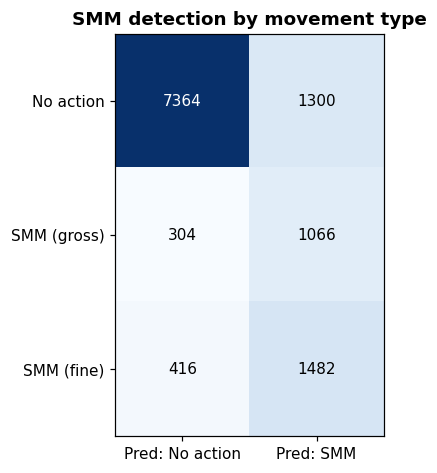

recall (gross-motor): 0.778   (1066/1370 detected)
recall (fine-motor): 0.781   (1482/1898 detected)


In [12]:
# three true groups: 0 = no action, 1 = gross SMM, 2 = fine SMM
true_grp = cat_te.copy()
disp_labels = ["No action", "SMM (gross)", "SMM (fine)"]

# build a 3x2 table: rows = true group, cols = predicted (no-action / SMM)
tbl = np.zeros((3, 2), int)
for g in (0, 1, 2):
    m = true_grp == g
    tbl[g, 0] = int((pred[m] == 0).sum())
    tbl[g, 1] = int((pred[m] == 1).sum())

fig, ax = plt.subplots(figsize=(5.4, 4.4))
im = ax.imshow(tbl, cmap="Blues")
ax.set_xticks([0, 1], ["Pred: No action", "Pred: SMM"])
ax.set_yticks([0, 1, 2], disp_labels)
for i in range(3):
    for j in range(2):
        ax.text(j, i, tbl[i, j], ha="center", va="center",
                color="white" if tbl[i, j] > tbl.max() / 2 else "black")
ax.set_title("SMM detection by movement type")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/confusion_by_type.png")
plt.show()

for g, name in [(1, "gross"), (2, "fine")]:
    m = true_grp == g
    r = pred[m].mean() if m.any() else float("nan")
    print(f"recall ({name}-motor): {r:.3f}   ({int(pred[m].sum())}/{int(m.sum())} detected)")

## 4. Notes for the report

* The threshold is the value stored at training time, chosen on the validation
  set to meet the recall target. Reusing it here keeps the test set unbiased —
  no quantity in this notebook is fitted to the test data.
* Because the operating point deliberately favours recall (missing an escalating
  child is worse than a false alert), the matrix is expected to show few false
  negatives and comparatively many false positives; the low precision this
  implies is by design, and the prototype's rolling-rate alerter suppresses
  isolated false positives before they reach the educator.
* `confusion_matrix.png` and `confusion_by_type.png` are written to `figures/`
  for inclusion in the evaluation chapter.